In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn import svm
from sklearn.preprocessing import StandardScaler


ModuleNotFoundError: No module named 'pandas'

Data Collection And Analysis From Dataset.

In [ ]:
Diabetes_data = pd.read_csv('C:\\Users\\USER\\Desktop\\Diabetes model\\diabetes_prediction_dataset.csv')
# Load the dataset and display the first few rows
Diabetes_data.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_status_never,smoking_status_past
0,Female,80.0,0,1,25.19,6.6,140.0,0,True,False
1,Female,54.0,0,0,27.32,6.6,80.0,0,False,False
2,Male,28.0,0,0,27.32,5.7,158.0,0,True,False
3,Female,36.0,0,0,23.45,5.0,155.0,0,False,False
4,Male,76.0,1,1,20.14,4.8,155.0,0,False,False


In [ ]:
# Checking for the number of rows and columns in the dataset
Diabetes_data.shape 

(100000, 10)

In [ ]:
# Statistics summary of the dataset
Diabetes_data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
#Checking for missing values in the dataset
Diabetes_data.isnull().sum()

gender                  0
age                     0
hypertension            0
heart_disease           0
bmi                     0
HbA1c_level             0
blood_glucose_level     0
diabetes                0
smoking_status_never    0
smoking_status_past     0
dtype: int64

In [ ]:
# Select a sample of age values for inspection
Diabetes_data_age = Diabetes_data['age'].head(1000)
Diabetes_data_age.head()


0      80.0
1      54.0
2      28.0
3      36.0
4      76.0
       ... 
995    62.0
996    44.0
997    21.0
998    45.0
999    43.0
Name: age, Length: 1000, dtype: float64

In [ ]:
# Select a sample of smoking history values for inspection
Diabetes_data_smoking_history = Diabetes_data['smoking_history'].head(1000)
Diabetes_data_smoking_history.head()


0        never
1      No Info
2        never
3      current
4      current
        ...   
995      never
996    No Info
997      never
998    current
999      never
Name: smoking_history, Length: 1000, dtype: object

In [ ]:
unique_values = Diabetes_data['smoking_history'].unique()
print(unique_values)
value_counts = Diabetes_data['smoking_history'].value_counts()
print(value_counts)
Diabetes_data_smoking_history[Diabetes_data_smoking_history.isin(['never', 'No Info','current','former','not current','ever'])].value_counts()

['never' 'No Info' 'current' 'former' 'ever' 'not current']
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


smoking_history
never          372
No Info        351
former          89
current         82
not current     62
ever            44
Name: count, dtype: int64

In [ ]:
Diabetes_data_smoking_history= Diabetes_data_smoking_history[Diabetes_data_smoking_history != 'No Info']


Diabetes_data_smoking_history.value_counts()


smoking_history
never          372
former          89
current         82
not current     62
ever            44
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_8000\1137461856.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.countplot(x='smoking_history', data=Diabetes_data_smoking_history.to_frame(), palette=['grey', 'red', 'lightblue', 'lightgreen', 'lightcoral', 'lightyellow'], hue='smoking_history')


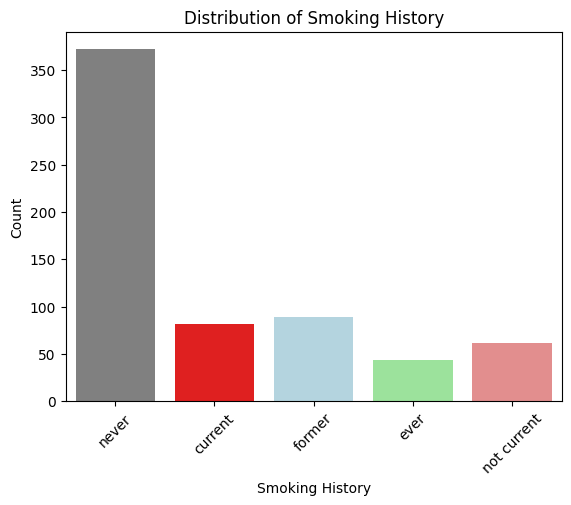

In [ ]:
#Visulaizing the smoking history distribution
# Visualizing the smoking history distribution
sns.countplot(x='smoking_history', data=Diabetes_data_smoking_history.to_frame(), palette=['grey', 'red', 'lightblue', 'lightgreen', 'lightcoral', 'lightyellow'], hue='smoking_history')
plt.title('Distribution of Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [ ]:

mapping = {
    'never': 'never',
    'former': 'past',
    'not current': 'past',
    'current': 'active',
    'ever': 'active'
}
Diabetes_data = Diabetes_data.rename(columns={'smoking_history': 'smoking_status'})
Diabetes_data['smoking_status'] = Diabetes_data['smoking_status'].map(mapping)

# Convert to binary columns
# We use drop_first=True to avoid the 'Dummy Variable Trap'
Diabetes_data = pd.get_dummies(Diabetes_data, columns=['smoking_status'], drop_first=True)

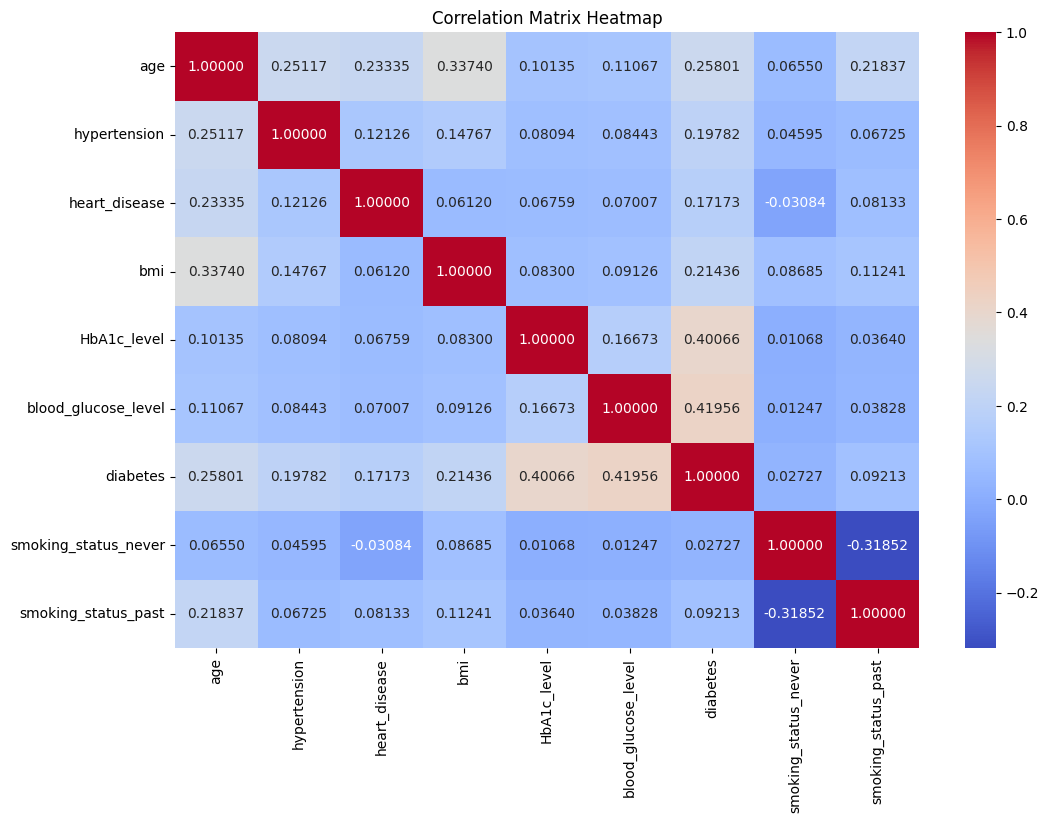

In [ ]:
# Calculate the correlation matrix
corr_matrix = Diabetes_data.drop('gender', axis=1).corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.5f')
plt.title("Correlation Matrix Heatmap")
plt.show()


In [ ]:
print(Diabetes_data['diabetes'].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [ ]:
Diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   gender                100000 non-null  object 
 1   age                   100000 non-null  float64
 2   hypertension          100000 non-null  int64  
 3   heart_disease         100000 non-null  int64  
 4   bmi                   100000 non-null  float64
 5   HbA1c_level           100000 non-null  float64
 6   blood_glucose_level   100000 non-null  int64  
 7   diabetes              100000 non-null  int64  
 8   smoking_status_never  100000 non-null  bool   
 9   smoking_status_past   100000 non-null  bool   
dtypes: bool(2), float64(3), int64(4), object(1)
memory usage: 6.3+ MB


In [ ]:
# Looking up the value counts of diagnosis
Diabetes_data['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

 0 - **Non-Diabetic Outcomes**.

1-  **Diabetic Outcomes**.

In [ ]:
# Checking for the data types of each column
Diabetes_data.dtypes

gender                   object
age                     float64
hypertension              int64
heart_disease             int64
bmi                     float64
HbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
smoking_status_never       bool
smoking_status_past        bool
dtype: object

In [ ]:
Diabetes_data['blood_glucose_level'] = Diabetes_data['blood_glucose_level'].astype(float)

In [ ]:
Diabetes_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   gender                100000 non-null  object 
 1   age                   100000 non-null  float64
 2   hypertension          100000 non-null  int64  
 3   heart_disease         100000 non-null  int64  
 4   bmi                   100000 non-null  float64
 5   HbA1c_level           100000 non-null  float64
 6   blood_glucose_level   100000 non-null  float64
 7   diabetes              100000 non-null  int64  
 8   smoking_status_never  100000 non-null  bool   
 9   smoking_status_past   100000 non-null  bool   
dtypes: bool(2), float64(4), int64(3), object(1)
memory usage: 6.3+ MB


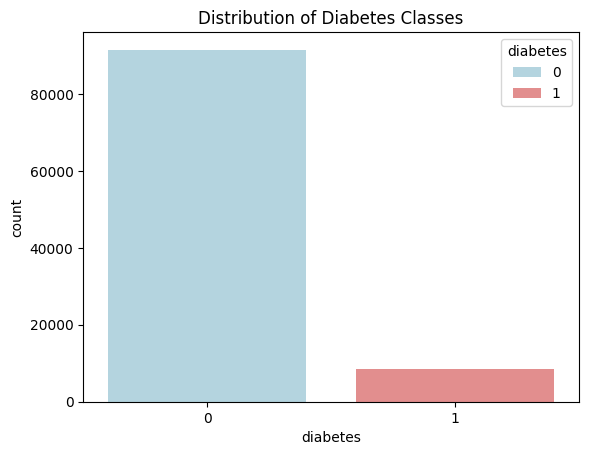

In [ ]:


sns.countplot(x='diabetes', data=Diabetes_data, hue='diabetes', palette=['lightblue', 'lightcoral'])
plt.title('Distribution of Diabetes Classes')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_8000\816830300.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(x='diabetes', y='blood_glucose_level', data=Diabetes_data, palette=['lightblue', 'lightcoral'])
C:\Users\USER\AppData\Local\Temp\ipykernel_8000\816830300.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='diabetes', y='blood_glucose_level', data=Diabetes_data, color='black', alpha=0.5, hue='diabetes')


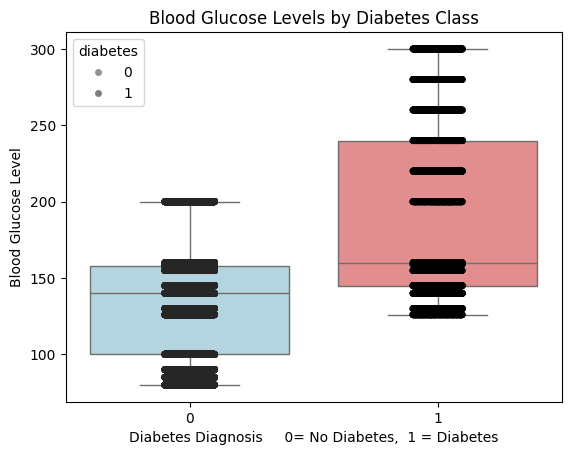

In [ ]:
boxplot = sns.boxplot(x='diabetes', y='blood_glucose_level', data=Diabetes_data, palette=['lightblue', 'lightcoral'])
sns.stripplot(x='diabetes', y='blood_glucose_level', data=Diabetes_data, color='black', alpha=0.5, hue='diabetes')
plt.title('Blood Glucose Levels by Diabetes Class')
plt.xlabel('Diabetes Diagnosis     0= No Diabetes,  1 = Diabetes')
plt.ylabel('Blood Glucose Level')
plt.show()

In [ ]:
# Seperating the data and the labels
X = Diabetes_data.drop('diabetes', axis=1)
y= Diabetes_data['diabetes']

In [ ]:
print(X)


       gender   age  hypertension  heart_disease    bmi  HbA1c_level  \
0      Female  80.0             0              1  25.19          6.6   
1      Female  54.0             0              0  27.32          6.6   
2        Male  28.0             0              0  27.32          5.7   
3      Female  36.0             0              0  23.45          5.0   
4        Male  76.0             1              1  20.14          4.8   
...       ...   ...           ...            ...    ...          ...   
99995  Female  80.0             0              0  27.32          6.2   
99996  Female   2.0             0              0  17.37          6.5   
99997    Male  66.0             0              0  27.83          5.7   
99998  Female  24.0             0              0  35.42          4.0   
99999  Female  57.0             0              0  22.43          6.6   

       blood_glucose_level  smoking_status_never  smoking_status_past  
0                    140.0                  True               

In [ ]:
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 100000, dtype: int64


Train-Test Split (Stratified)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Model Selection

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validat
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
%pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42))
    ]),
}


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "roc_auc": "roc_auc"
}

# -------------------------------
# 5. TRAIN + CROSS-VALIDATE
# -------------------------------
results = {}

for name, model in models.items():
    categorical_features = ["gender"]
    numeric_features = [col for col in X_train.columns if col not in categorical_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
        ]
    )

    models = {
        "Logistic Regression": Pipeline([
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
        ]),
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
        ]),
        "XGBoost": Pipeline([
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)),
        ]),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {
        "f1": "f1",
        "recall": "recall",
        "precision": "precision",
        "roc_auc": "roc_auc"
    }

    # -------------------------------
    # 5. TRAIN + CROSS-VALIDATE
    # -------------------------------
    results = {}

    for name, model in models.items():
        scores = cross_validate(model, X_train, y_train,
                                cv=cv,
                                scoring=scoring,
                                return_train_score=False)

        results[name] = {
            metric: np.mean(scores[f"test_{metric}"])
            for metric in scoring
        }

    # Display CV results
    print("\n=== Cross-Validation Results ===")
    for model_name, metrics in results.items():
        print(f"\n{model_name}")
        for k, v in metrics.items():
            print(f"{k}: {v:.3f}")

    # -------------------------------
    # 6. FINAL TRAINING + TEST EVALUATION
    # -------------------------------
    print("\n=== Test Set Evaluation ===")

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        print(f"\n{name}")
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        roc = roc_auc_score(y_test, y_proba)

        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)

        print(f"ROC-AUC: {roc:.3f}")
        print(f"PR-AUC: {pr_auc:.3f}")

    results[name] = {
        metric: np.mean(scores[f"test_{metric}"])
        for metric in scoring
    }

# Display CV results
print("\n=== Cross-Validation Results ===")
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    for k, v in metrics.items():
        print(f"{k}: {v:.3f}")

# -------------------------------
# 6. FINAL TRAINING + TEST EVALUATION
# -------------------------------
print("\n=== Test Set Evaluation ===")

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    roc = roc_auc_score(y_test, y_proba)

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    print(f"ROC-AUC: {roc:.3f}")
    print(f"PR-AUC: {pr_auc:.3f}")

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [20:05:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 640x480 with 0 Axes>

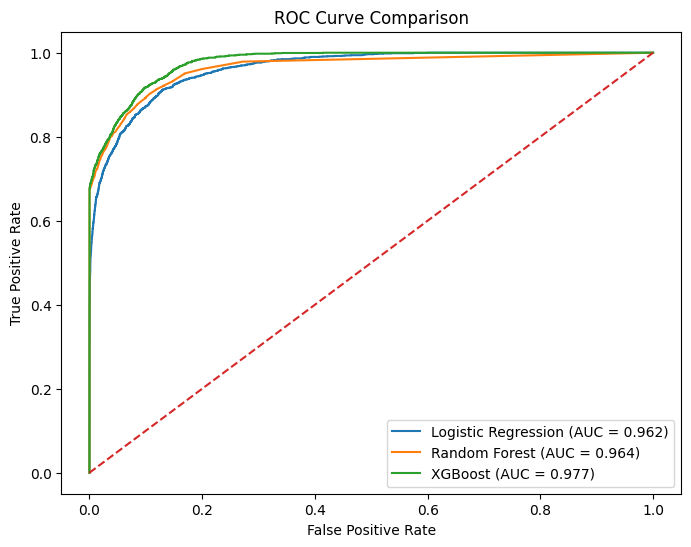

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [20:05:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


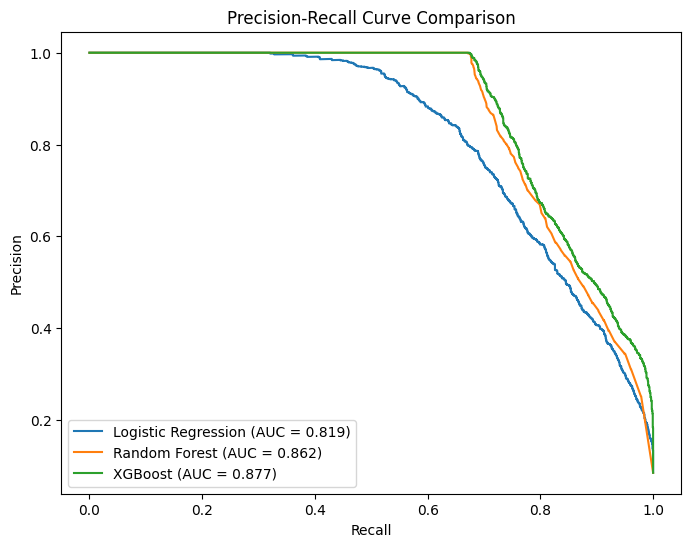

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

plt.figure()

# ROC CURVES
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# PRECISION-RECALL CURVES
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()